# Transformer

Neste notebook, vamos implementar um modelo encoder-decoder baseado no **Transformer**, uma arquitetura que substituiu as RNNs em muitas tarefas de NLP e se tornou o padrão em tradução automática e modelos de linguagem modernos.

Ao longo da implementação, serão revisados os principais componentes da arquitetura, como Self-Attention, Encoder e Decoder, além da implementação desses módulos em PyTorch, construção de um modelo completo de tradução português-inglês, treinamento em um conjunto de dados de exemplo e avaliação da qualidade das traduções geradas.

In [1]:
import re
import math
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.model_selection import train_test_split

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


### Positional Encoding

Transformers não possuem mecanismos recorrentes ou convolucionais, o que significa que eles não têm uma noção implícita da ordem dos tokens em uma sequência. Para incorporar essa informação, é adicionada uma codificação posicional aos vetores de embedding. Essa codificação é determinística e baseada em funções senoidais de diferentes frequências.

A codificação posicional utilizada segue a formulação original do paper *"Attention is All You Need"*:

$$
PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
$$

$$
PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
$$

Onde:
- $pos$ representa a posição do token na sequência,
- $i$ é o índice da dimensão do embedding,
- $d_{\text{model}}$ é a dimensionalidade do embedding.

O resultado é uma matriz de codificação com forma $(1, \text{max\_len}, d_{\text{model}})$ que é somada diretamente aos embeddings de entrada.

In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        self.d_model = d_model

        # matriz (max_len, d_model)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # (max_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        # seno nas posições pares, cosseno nas ímpares
        pe[:, 0::2] = torch.sin(position * div_term)  # pares
        pe[:, 1::2] = torch.cos(position * div_term)  # ímpares

        pe = pe.unsqueeze(0)  # (1, max_len, d_model) -> broadcast no batch
        self.register_buffer("pe", pe)  # não é parâmetro treinável

    def forward(self, x):
        T = x.size(1)
        x = x + self.pe[:, :T, :]  # (B, T, d_model)
        return x

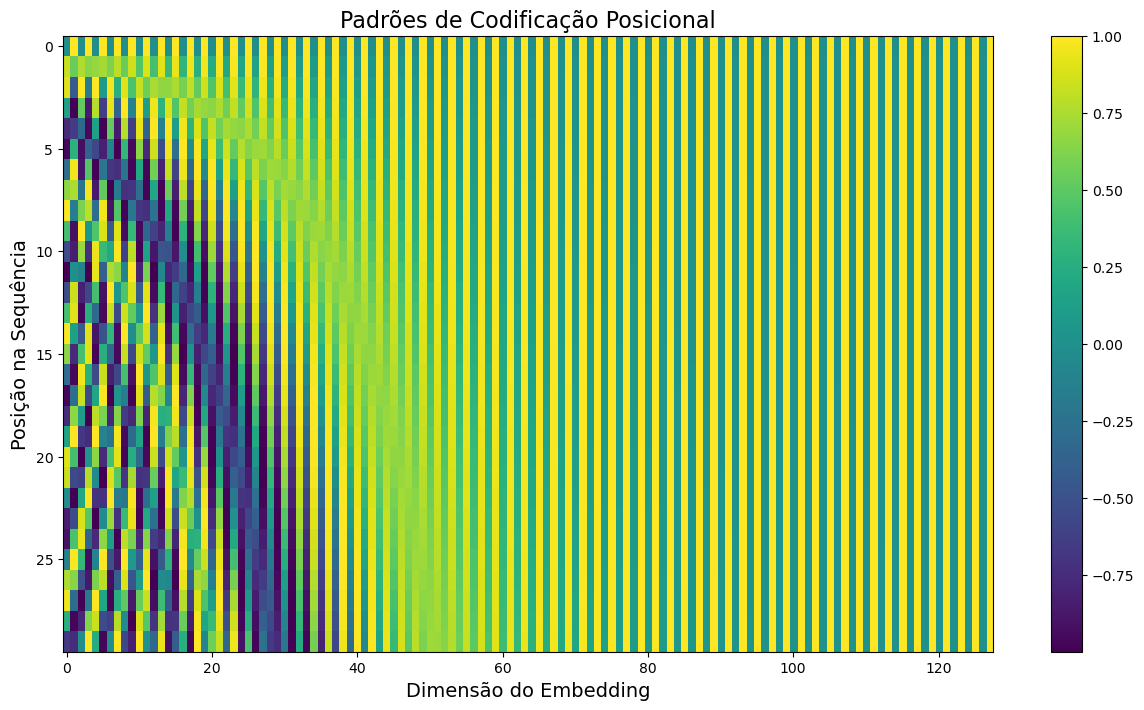

In [4]:
# Visualizar padrões de codificação posicional
d_model = 128
seq_len = 30

pos_enc = PositionalEncoding(d_model=d_model, max_len=seq_len)
pe_only = pos_enc.pe[0, :seq_len, :].numpy()

plt.figure(figsize=(15, 8))
plt.imshow(pe_only, cmap='viridis', aspect='auto')
plt.colorbar()
plt.title('Padrões de Codificação Posicional', fontsize=16)
plt.xlabel('Dimensão do Embedding', fontsize=14)
plt.ylabel('Posição na Sequência', fontsize=14)
plt.show()

In [5]:
d_model = 16
num_heads = 4
B, T = 2, 5

# embeddings simulados
x = torch.randn(B, T, d_model)

# positional encoding
pos_enc = PositionalEncoding(d_model)
x = pos_enc(x)  # adiciona posições

print("Positional Encoding:", x.shape)  # (B, T, d_model)

Positional Encoding: torch.Size([2, 5, 16])


### Multi-Head Attention

O mecanismo de **multi-head attention** é um dos blocos centrais dos Transformers. Ele permite que o modelo foque em diferentes partes da sequência em paralelo, usando múltiplas "cabeças" de atenção. Cada cabeça realiza uma atenção com projeções diferentes dos vetores de entrada, e seus resultados são combinados ao final.

A atenção é baseada no mecanismo de **Scaled Dot-Product Attention**, que recebe três vetores: $Q$ (query), $K$ (key) e $V$ (value). O cálculo da atenção segue a fórmula:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V
$$

Onde:
- $Q$, $K$ e $V$ são tensores projetados a partir da entrada,
- $d_k$ é a dimensionalidade das chaves (key),
- A divisão por $\sqrt{d_k}$ serve para normalizar os scores e evitar valores muito grandes que podem saturar a softmax.

No caso de múltiplas cabeças, os vetores $Q$, $K$ e $V$ são divididos em $h$ partes (cabeças), cada uma com dimensionalidade reduzida $d_k = d_{\text{model}} / h$, aplicando a atenção de forma independente em cada cabeça. Os resultados são então concatenados e projetados novamente com uma camada linear:

$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W^O
$$

Cada cabeça é computada como:

$$
\text{head}_i = \text{Attention}(Q W_i^Q, K W_i^K, V W_i^V)
$$

Esse paralelismo permite que diferentes aspectos contextuais da sequência sejam aprendidos simultaneamente. Essa implementação define todas as projeções lineares necessárias, faz o `split_heads`, aplica a atenção escalada, combina os resultados com `combine_heads`, e projeta de volta para o espaço original com uma camada linear $W^O$.

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model deve ser divisível por num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        # Projeções lineares
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)

        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        B, Tq, _ = q.size()
        Tk = k.size(1)
        Tv = v.size(1)

        # Projeções
        Q = self.q_proj(q)
        K = self.k_proj(k)
        V = self.v_proj(v)

        # Split heads
        Q = Q.view(B, Tq, self.num_heads, self.head_dim).transpose(1, 2)  # (B, h, Tq, d_head)
        K = K.view(B, Tk, self.num_heads, self.head_dim).transpose(1, 2)  # (B, h, Tk, d_head)
        V = V.view(B, Tv, self.num_heads, self.head_dim).transpose(1, 2)  # (B, h, Tv, d_head)

        # Atenção
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)  # (B, h, Tq, Tk)

        if mask is not None:
            # mask: (B, 1, 1, Tk) ou (B, 1, Tq, Tk)
            attn_scores = attn_scores.masked_fill(mask == 0, float("-inf"))

        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_output = torch.matmul(attn_weights, V)  # (B, h, Tq, d_head)

        # Junta os heads
        attn_output = attn_output.transpose(1, 2).contiguous().view(B, Tq, self.d_model)

        return self.out_proj(attn_output)

#### Máscaras no Transformer

Para que o Transformer funcione corretamente, especialmente em tarefas autoregressivas e no tratamento de sequências de comprimentos variados, utilizamos **máscaras**:

1. **Máscara de Padding**: Sequências em um batch geralmente têm comprimentos diferentes e são preenchidas com o token especial `<pad>` (geralmente mapeado para o índice 0). Para evitar que a atenção considere os tokens `<pad>`, aplicamos uma máscara que zera a atenção nessas posições.
2. **Máscara Causal (Look-Ahead Mask)**: No Decoder (self-attention), o modelo prevê o próximo token da sequência de forma autoregressiva. Para evitar que o modelo olhe para os tokens futuros durante o treinamento, aplicamos uma máscara triangular inferior. Ela garante que a representação no passo $t$ dependa apenas dos tokens nas posições $\leq t$.


In [7]:
def causal_mask(seq_len, device=None):
    """
    Cria máscara causal triangular inferior.
    shape: (1, 1, seq_len, seq_len)
    """
    mask = torch.tril(torch.ones(seq_len, seq_len, device=device))
    return mask.unsqueeze(0).unsqueeze(0)  # (1, 1, T, T)


def padding_mask(pad_tokens, device=None):
    """
    Cria máscara de padding.
    pad_tokens: tensor (B, T) com 1 onde é token válido e 0 onde é padding
    retorna shape: (B, 1, 1, T) -> broadcast em atenção
    """
    return pad_tokens.unsqueeze(1).unsqueeze(2).to(device)  # (B,1,1,T)

In [8]:
# Exemplo de uso
d_model = 16
num_heads = 4
B, T = 2, 5

x = torch.randn(B, T, d_model)
mask = causal_mask(T, device=x.device)
attn = MultiHeadAttention(d_model=d_model, num_heads=num_heads)

out = attn(x, x, x, mask=mask)
print("Self-Attention:", out.shape)  # (B, T, d_model)

Self-Attention: torch.Size([2, 5, 16])


### Feed-Forward Layer

Em Transformers, cada bloco contém uma **camada feed-forward totalmente conectada** que é aplicada de forma independente a cada posição da sequência. Essa camada é responsável por aprender transformações não-lineares locais após o mecanismo de atenção.

A arquitetura típica de uma feed-forward layer é composta por duas camadas lineares com uma função de ativação não-linear (geralmente ReLU) no meio:

$$
\text{FFN}(x) = W_2 \cdot \text{ReLU}(W_1 \cdot x + b_1) + b_2
$$

Onde:
- $x$ é o vetor de entrada de dimensão $d_{\text{model}}$,
- $W_1 \in \mathbb{R}^{d_{\text{ff}} \times d_{\text{model}}}$ e $W_2 \in \mathbb{R}^{d_{\text{model}} \times d_{\text{ff}}}$ são pesos aprendidos,
- $d_{\text{ff}}$ é a dimensionalidade intermediária (maior que $d_{\text{model}}$ para aumentar a capacidade do modelo),
- $\text{ReLU}(x) = \max(0, x)$ é a função de ativação não-linear.

Essa camada é aplicada posição a posição (de forma independente em cada token), e introduz não-linearidades e capacidade de transformação mais complexa ao modelo, além de expandir e comprimir a dimensionalidade, o que funciona como um "bottleneck" informativo.

In [9]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(self.relu(self.fc1(x))))

In [10]:
# Exemplo
d_model = 512
d_ff = 2048
B, T = 2, 5

feed_forward = FeedForward(d_model, d_ff)

query = torch.randn(B, T, d_model)  # (B, T, d_model)
output = feed_forward(query)

print(f'Input shape: {query.shape}')  # Input shape: (B, T, d_model)
print(f'Output shape: {output.shape}')  # Output shape: (B, T, d_model)

Input shape: torch.Size([2, 5, 512])
Output shape: torch.Size([2, 5, 512])


### EncoderLayer e Encoder

Cada `EncoderLayer` é composta por dois blocos: atenção multi-cabeça seguida de normalização, e uma feed-forward seguida de outra normalização. Em ambos os casos, há conexões residuais e dropout:

$$
x_1 = \text{LayerNorm}(x + \text{Dropout}(\text{MultiHead}(x, x, x)))
$$

$$
\text{Output} = \text{LayerNorm}(x_1 + \text{Dropout}(\text{FFN}(x_1)))
$$

A classe `Encoder` empilha múltiplas `EncoderLayer`s após converter os tokens com `Embedding` e adicionar codificações posicionais. O fluxo é:

$$
x = \text{Embedding}(x) + \text{PositionalEncoding}
$$

$$
x = \text{EncoderLayer}_N \circ \cdots \circ \text{EncoderLayer}_1 (x)
$$

Esse processo transforma a sequência de entrada em uma representação contextualizada, onde cada posição é influenciada pelas demais.

In [11]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward  = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask=None):
        # Self-Attention
        attn_out = self.self_attn(x, x, x, mask=src_mask)
        x = x + self.dropout(attn_out)
        x = self.norm1(x)

        # FeedForward
        ff_out = self.feed_forward(x)
        x = x + self.dropout(ff_out)
        x = self.norm2(x)
        return x

In [12]:
# Modelo
d_model = 32
num_heads = 4
d_ff = 64

encoder_layer = EncoderLayer(d_model, num_heads, d_ff)

# Exemplo
batch_size = 4
seq_len = 10

x = torch.randn(batch_size, seq_len, d_model)
out = encoder_layer(x)

print(f"Input shape: {x.shape}")    # (N, T, d_model)
print(f"Output shape: {out.shape}") # (N, T, d_model)

Input shape: torch.Size([4, 10, 32])
Output shape: torch.Size([4, 10, 32])


In [13]:
class Encoder(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, src_mask=None):
        for layer in self.layers:
            x = layer(x, src_mask)
        return self.norm(x)

In [14]:
# Modelo
d_model = 32
num_heads = 4
d_ff = 64
num_layers = 3

encoder = Encoder(d_model, num_heads, d_ff, num_layers)

# Exemplo
batch_size = 4
seq_len = 12

x = torch.randn(batch_size, seq_len, d_model)
out = encoder(x)

print(f"Input shape: {x.shape}")     # (N, T, d_model)
print(f"Encoder output: {out.shape}") # (N, T, d_model)

Input shape: torch.Size([4, 12, 32])
Encoder output: torch.Size([4, 12, 32])


### DecoderLayer e Decoder

Cada `DecoderLayer` possui três blocos com conexões residuais e normalização:

1. **Self-attention mascarada**: impede que o token atual veja os futuros.
2. **Cross-attention**: permite que o decoder atenda à saída do encoder.
3. **Feed-forward**: transformação não linear local.

As operações são:

$$
x_1 = \text{LayerNorm}(x + \text{Dropout}(\text{SelfAttn}(x)))
$$

$$
x_2 = \text{LayerNorm}(x_1 + \text{Dropout}(\text{CrossAttn}(x_1, \text{enc\_out})))
$$

$$
\text{Output} = \text{LayerNorm}(x_2 + \text{Dropout}(\text{FFN}(x_2)))
$$

O `Decoder` empilha múltiplas `DecoderLayer`s após aplicar embedding e codificação posicional, e gera uma distribuição sobre o vocabulário via uma camada linear final.

In [15]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1, cross_attention=True):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attention = cross_attention
        if cross_attention:
            self.cross_attn = MultiHeadAttention(d_model, num_heads)

        self.feed_forward = FeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model) if cross_attention else None
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out=None, tgt_mask=None, memory_mask=None):
        # Masked Self-Attention
        attn_out = self.self_attn(x, x, x, mask=tgt_mask)
        x = x + self.dropout(attn_out)
        x = self.norm1(x)

        # Cross-Attention (se habilitado)
        if self.cross_attention and enc_out is not None:
            attn_out = self.cross_attn(x, enc_out, enc_out, mask=memory_mask)
            x = x + self.dropout(attn_out)
            x = self.norm2(x)

        # FeedForward
        ff_out = self.feed_forward(x)
        x = x + self.dropout(ff_out)
        x = self.norm3(x)

        return x

In [16]:
# Modelo
d_model = 32
num_heads = 4
d_ff = 64

decoder_layer = DecoderLayer(d_model, num_heads, d_ff)

# Exemplo
batch_size = 4
src_len = 15
tgt_len = 7

enc_out = torch.randn(batch_size, src_len, d_model)  # saída do encoder
tgt = torch.randn(batch_size, tgt_len, d_model)      # entrada do decoder

tgt_mask = causal_mask(tgt_len)

out = decoder_layer(tgt, enc_out, tgt_mask=tgt_mask)

print(f"Target input: {tgt.shape}")        # (N, T_tgt, d_model)
print(f"DecoderLayer output: {out.shape}") # (N, T_tgt, d_model)

Target input: torch.Size([4, 7, 32])
DecoderLayer output: torch.Size([4, 7, 32])


In [17]:
class Decoder(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_layers, dropout=0.1, cross_attention=True):
        super().__init__()
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout, cross_attention)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, enc_out=None, tgt_mask=None, memory_mask=None):
        for layer in self.layers:
            x = layer(x, enc_out, tgt_mask, memory_mask)
        return self.norm(x)

In [18]:
# Modelo
d_model = 32
num_heads = 4
d_ff = 64
num_layers = 2

decoder = Decoder(d_model, num_heads, d_ff, num_layers)

# Exemplo
batch_size = 4
src_len = 15
tgt_len = 7

enc_out = torch.randn(batch_size, src_len, d_model)
tgt = torch.randn(batch_size, tgt_len, d_model)

tgt_mask = causal_mask(tgt_len)

out = decoder(tgt, enc_out, tgt_mask=tgt_mask)

print(f"Decoder input: {tgt.shape}")     # (N, T_tgt, d_model)
print(f"Decoder output: {out.shape}")    # (N, T_tgt, d_model)

Decoder input: torch.Size([4, 7, 32])
Decoder output: torch.Size([4, 7, 32])


### Transformer

A classe `Transformer` combina o encoder e o decoder em uma arquitetura completa de tradução seq2seq. Ela segue o formato proposto por Vaswani et al. (2017), onde:

- O **encoder** processa a sequência de entrada e gera representações contextuais.
- O **decoder** gera a saída passo a passo, utilizando essas representações.

#### Máscaras

Durante o `forward`, são geradas duas máscaras:
- **Máscara de padding**: impede atenção a tokens vazios (`src == 0` ou `trg == 0`).
- **Máscara causal (no-peak)**: impede que a atenção no decoder veja posições futuras, garantindo autoregressividade. Ela é definida por:

$$
\text{nopeak}_{i,j} = \begin{cases}
1, & \text{se } j \leq i \\
0, & \text{caso contrário}
\end{cases}
$$

O fluxo geral é:

$$
\text{EncoderOutput} = \text{Encoder}(src, src\_mask)
$$

$$
\text{Output} = \text{Decoder}(trg, \text{EncoderOutput}, src\_mask, trg\_mask)
$$

In [19]:
class Transformer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_encoder_layers, num_decoder_layers,
                 src_vocab_size, tgt_vocab_size, max_len=5000, dropout=0.1):
        super().__init__()

        # embeddings separados
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)

        # positional encoding
        self.pos_encoding = PositionalEncoding(d_model, max_len)

        # encoder e decoder
        self.encoder = Encoder(d_model, num_heads, d_ff, num_encoder_layers, dropout)
        self.decoder = Decoder(d_model, num_heads, d_ff, num_decoder_layers, dropout)

        # projeção final para o vocabulário de saída
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None, memory_mask=None):
        """
        src: (N, T_src) índices dos tokens da entrada
        tgt: (N, T_tgt) índices dos tokens da saída
        """
        # embeddings + posições
        src_emb = self.src_embedding(src) * (self.src_embedding.embedding_dim ** 0.5)
        src_emb = self.pos_encoding(src_emb)

        tgt_emb = self.tgt_embedding(tgt) * (self.tgt_embedding.embedding_dim ** 0.5)
        tgt_emb = self.pos_encoding(tgt_emb)

        # encoder
        memory = self.encoder(src_emb, src_mask)

        # decoder
        out = self.decoder(tgt_emb, memory, tgt_mask, memory_mask)

        # projeção final para vocabulário alvo
        logits = self.fc_out(out)  # (N, T_tgt, tgt_vocab_size)

        return logits

In [20]:
# Modelo
d_model = 32
num_heads = 4
d_ff = 64
num_encoder_layers = 2
num_decoder_layers = 2
src_vocab_size = 120   # ex: português
tgt_vocab_size = 150   # ex: inglês
max_len = 50

model = Transformer(d_model, num_heads, d_ff, num_encoder_layers, num_decoder_layers, src_vocab_size, tgt_vocab_size, max_len)

# Exemplo
batch_size = 4
src_len = 12
tgt_len = 8

src = torch.randint(0, src_vocab_size, (batch_size, src_len))  # tokens de entrada
tgt = torch.randint(0, tgt_vocab_size, (batch_size, tgt_len))  # tokens de saída

tgt_mask = causal_mask(tgt_len)

out = model(src, tgt, tgt_mask=tgt_mask)

print(f"Source input shape: {src.shape}")   # (N, T_src)
print(f"Target input shape: {tgt.shape}")   # (N, T_tgt)
print(f"Output shape: {out.shape}")         # (N, T_tgt, tgt_vocab_size)

Source input shape: torch.Size([4, 12])
Target input shape: torch.Size([4, 8])
Output shape: torch.Size([4, 8, 150])


## Tradução

In [21]:
class Tokenizer:
    def __init__(self, special_tokens=None, lowercase=True, split_pattern=None, filter_pattern=None):
        self.special_tokens = special_tokens or []
        self.lowercase = lowercase
        self.split_pattern = split_pattern
        self.filter_pattern = filter_pattern
        self.stoi = {}
        self.itos = {}

    def tokenize(self, text):
        if self.lowercase:
            text = text.lower()
        if self.filter_pattern:
            text = re.sub(self.filter_pattern, '', text)
        if self.split_pattern:
            return re.findall(self.split_pattern, text)
        return text.split()

    def fit(self, texts, min_freq=1):
        word_counts = Counter()
        for text in texts:
            word_counts.update(self.tokenize(text))
        self.stoi = {tok: idx for idx, tok in enumerate(self.special_tokens)}
        for word, count in sorted(word_counts.items(), key=lambda x: x[0]):
            if count >= min_freq and word not in self.stoi:
                self.stoi[word] = len(self.stoi)
        self.itos = {idx: word for word, idx in self.stoi.items()}

    def encode(self, text, max_len=None, add_sos=False, add_eos=False):
        tokens = self.tokenize(text)
        unk_idx = self.stoi.get("<unk>", 0)
        pad_idx = self.stoi.get("<pad>", 0)
        sos_idx = self.stoi.get("<sos>", 0)
        eos_idx = self.stoi.get("<eos>", 0)
        ids = [self.stoi.get(tok, unk_idx) for tok in tokens]
        if add_sos:
            ids = [sos_idx] + ids
        if add_eos:
            ids = ids + [eos_idx]
        if max_len is not None:
            if len(ids) < max_len:
                ids += [pad_idx] * (max_len - len(ids))
            else:
                ids = ids[:max_len]
        return ids

    def decode(self, ids):
        return [self.itos.get(idx, "<unk>") for idx in ids]


In [22]:
class Tokenizer:
    def __init__(self, special_tokens=None, lowercase=True, split_pattern=None, filter_pattern=None):
        self.special_tokens = special_tokens or []
        self.lowercase = lowercase
        self.split_pattern = split_pattern
        self.filter_pattern = filter_pattern
        self.stoi = {}
        self.itos = {}
        
    def tokenize(self, text):
        if self.lowercase:
            text = text.lower()
        if self.filter_pattern:
            text = re.sub(self.filter_pattern, '', text)
        if self.split_pattern:
            return re.findall(self.split_pattern, text)
        return text.split()
        
    def fit(self, texts, min_freq=1):
        word_counts = Counter()
        for text in texts:
            word_counts.update(self.tokenize(text))
            
        self.stoi = {tok: idx for idx, tok in enumerate(self.special_tokens)}
        
        for word, count in sorted(word_counts.items(), key=lambda x: x[0]):
            if count >= min_freq and word not in self.stoi:
                self.stoi[word] = len(self.stoi)
                
        self.itos = {idx: word for word, idx in self.stoi.items()}
        
    def encode(self, text, max_len=None, add_sos=False, add_eos=False):
        tokens = self.tokenize(text)
        unk_idx = self.stoi.get("<unk>", 0)
        pad_idx = self.stoi.get("<pad>", 0)
        sos_idx = self.stoi.get("<sos>", 0)
        eos_idx = self.stoi.get("<eos>", 0)
        
        ids = [self.stoi.get(tok, unk_idx) for tok in tokens]
        
        if add_sos:
            ids = [sos_idx] + ids
        if add_eos:
            ids = ids + [eos_idx]
            
        if max_len is not None:
            if len(ids) < max_len:
                ids += [pad_idx] * (max_len - len(ids))
            else:
                ids = ids[:max_len]
        return ids
        
    def decode(self, ids):
        return [self.itos.get(idx, "<unk>") for idx in ids]


In [24]:
pairs = [
    ("olá", "hello"),
    ("bom dia", "good morning"),
    ("boa noite", "good night"),
    ("como vai?", "how are you?"),
    ("estou bem", "i am fine"),
    ("obrigado", "thank you"),
    ("até logo", "see you later"),
    ("sim", "yes"),
    ("não", "no"),
    ("eu gosto de café", "i like coffee"),
    ("ela gosta de música", "she likes music"),
    ("nós vamos para a escola", "we go to school"),
    ("ele está em casa", "he is at home"),
    ("onde você está?", "where are you?"),
    ("o gato está na cadeira", "the cat is on the chair"),
]

In [25]:
src_tokenizer = Tokenizer(special_tokens=["<pad>", "<sos>", "<eos>", "<unk>"])
src_tokenizer.fit([pt for pt, en in pairs])
tgt_tokenizer = Tokenizer(special_tokens=["<pad>", "<sos>", "<eos>", "<unk>"])
tgt_tokenizer.fit([en for pt, en in pairs])
src_vocab_size = len(src_tokenizer.stoi)
tgt_vocab_size = len(tgt_tokenizer.stoi)
print(f"Tamanho do vocabulário de origem (PT): {src_vocab_size}")
print(f"Tamanho do vocabulário de destino (EN): {tgt_vocab_size}")

Tamanho do vocabulário de origem (PT): 41
Tamanho do vocabulário de destino (EN): 38


In [27]:
def encode_sentence(sentence, tokenizer, max_len=10):
    return tokenizer.encode(sentence, max_len=max_len, add_sos=True, add_eos=True)

max_len = 10
data = [
    (encode_sentence(pt, src_tokenizer, max_len), encode_sentence(en, tgt_tokenizer, max_len))
    for pt, en in pairs
]
src_data = torch.tensor([pt for pt, en in data])
tgt_data = torch.tensor([en for pt, en in data])

print("src_data shape:", src_data.shape)
print("tgt_data shape:", tgt_data.shape)

src_data shape: torch.Size([15, 10])
tgt_data shape: torch.Size([15, 10])


In [28]:
# Exemplo de entrada e saída para tradução
idx_ex = 0
ex_pt, ex_en = pairs[idx_ex]
ex_src_ids = src_data[idx_ex]
ex_tgt_ids = tgt_data[idx_ex]
print("--- Exemplo de Tradução (Dataset) ---")
print("Texto de entrada (PT):", ex_pt)
print("IDs de entrada (PT):  ", ex_src_ids.tolist())
print("Texto alvo (EN):      ", ex_en)
print("IDs alvo (EN):        ", ex_tgt_ids.tolist())
print("Tokens de entrada decodificados:", src_tokenizer.decode(ex_src_ids.tolist()))
print("Tokens alvo decodificados:     ", tgt_tokenizer.decode(ex_tgt_ids.tolist()))

--- Exemplo de Tradução (Dataset) ---
Texto de entrada (PT): olá
IDs de entrada (PT):   [1, 34, 2, 0, 0, 0, 0, 0, 0, 0]
Texto alvo (EN):       hello
IDs alvo (EN):         [1, 14, 2, 0, 0, 0, 0, 0, 0, 0]
Tokens de entrada decodificados: ['<sos>', 'olá', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
Tokens alvo decodificados:      ['<sos>', 'hello', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


In [29]:
d_model = 64
num_heads = 4
d_ff = 256
num_encoder_layers = 2
num_decoder_layers = 2

model = Transformer(
    d_model, num_heads, d_ff,
    num_encoder_layers, num_decoder_layers,
    src_vocab_size, tgt_vocab_size, max_len,
    dropout=0.3
).to(device)

In [30]:
criterion = nn.CrossEntropyLoss(ignore_index=tgt_tokenizer.stoi["<pad>"])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [31]:
epochs = 50
batch_size = 4

for epoch in range(epochs):
    total_loss = 0
    for i in range(0, len(src_data), batch_size):
        src_batch = src_data[i:i+batch_size].to(device)
        tgt_batch = tgt_data[i:i+batch_size].to(device)
        tgt_in = tgt_batch[:, :-1]
        tgt_out = tgt_batch[:, 1:]
        tgt_mask = causal_mask(tgt_in.size(1)).to(device)
        logits = model(src_batch, tgt_in, tgt_mask=tgt_mask)
        loss = criterion(logits.reshape(-1, tgt_vocab_size), tgt_out.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 10, Loss: 6.2807
Epoch 20, Loss: 2.5762
Epoch 30, Loss: 1.1853
Epoch 40, Loss: 0.5761
Epoch 50, Loss: 0.3932


In [32]:
def greedy_translate(model, src_sentence, max_len=10):
    model.eval()
    src_ids = torch.tensor([encode_sentence(src_sentence, src_tokenizer, max_len)]).to(device)
    tgt_ids = torch.tensor([[tgt_tokenizer.stoi["<sos>"]]]).to(device)
    for _ in range(max_len-1):
        tgt_mask = causal_mask(tgt_ids.size(1), device=device)
        logits = model(src_ids, tgt_ids, tgt_mask=tgt_mask)
        next_token = logits[:, -1, :].argmax(-1).unsqueeze(0)
        tgt_ids = torch.cat([tgt_ids, next_token], dim=1)
        if next_token.item() == tgt_tokenizer.stoi["<eos>"]:
            break
    return " ".join([tgt_tokenizer.itos[i.item()] for i in tgt_ids[0]])

print(greedy_translate(model, "o gato gosta da casa"))

<sos> i am fine <eos>


## Classificação

Nesta seção, implementamos um módulo de classificação de texto utilizando **apenas o Encoder do Transformer**.

O modelo:
- Recebe uma sequência de índices de tokens como entrada.
- Passa os embeddings pela pilha de camadas do Encoder.
- Agrega a informação da sequência por meio de um **pooling de média na dimensão temporal** (`seq_len`).
- Passa o vetor resultante por uma camada linear para prever a classe.

O dataset utilizado é o **20 Newsgroups**, filtrado em algumas categorias de notícias.


In [33]:
from sklearn.datasets import fetch_20newsgroups

categories = ['sci.electronics', 'comp.graphics', 'sci.med', 'rec.motorcycles']
max_len = 100
batch_size = 32

newsgroups_data = fetch_20newsgroups(subset='all', categories=categories)
texts = newsgroups_data.data[:5000]
labels = newsgroups_data.target[:5000]

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

class_tokenizer = Tokenizer(
    special_tokens=["<pad>", "<unk>"],
    lowercase=True,
    filter_pattern=r'[^a-z\s]'
)
class_tokenizer.fit(train_texts, min_freq=2)
class_vocab_size = len(class_tokenizer.stoi)
print(f"Tamanho do vocabulário de classificação: {class_vocab_size}")

Tamanho do vocabulário de classificação: 23026


In [37]:
class NewsGroupsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        token_ids = self.tokenizer.encode(text, max_len=self.max_len)
        return torch.tensor(token_ids, dtype=torch.long), label

train_dataset = NewsGroupsDataset(train_texts, train_labels, class_tokenizer, max_len)
val_dataset = NewsGroupsDataset(val_texts, val_labels, class_tokenizer, max_len)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)

# Exemplo de entrada e saída para classificação
idx_ex = 0
ex_text = train_texts[idx_ex]
ex_label = train_labels[idx_ex]
ex_label_name = categories[ex_label]
ex_ids, _ = train_dataset[idx_ex]
print("--- Exemplo de Classificação (Dataset) ---")
print("Texto bruto (primeiros 250 caracteres):")
print(ex_text[:250] + "...")
print(f"\nClasse alvo: {ex_label} ({ex_label_name})")
print("IDs de entrada tokenizados (primeiros 30 tokens):", ex_ids[:30].tolist())
print("Tokens correspondentes decodificados:", class_tokenizer.decode(ex_ids[:30].tolist()))

--- Exemplo de Classificação (Dataset) ---
Texto bruto (primeiros 250 caracteres):
Subject: Re: Kawi Zephyr? (was Re: Vision vs GpZ 550)
From: REE700A@MAINE.MAINE.EDU
Organization: University of Maine System
Lines: 17

I don't know about the dinky little Zephyr's, but the 1100 (now
the ZR1100) looks alot like my '76 Z1/ KZ900!  The...

Classe alvo: 1 (comp.graphics)
IDs de entrada tokenizados (primeiros 30 tokens): [19738, 16688, 10963, 22978, 22180, 16688, 21960, 22062, 8488, 7913, 16872, 14475, 21457, 14253, 12192, 20116, 11776, 9640, 5992, 11203, 58, 20482, 5661, 11842, 1, 2815, 20482, 14044, 20482, 23013]
Tokens correspondentes decodificados: ['subject', 're', 'kawi', 'zephyr', 'was', 're', 'vision', 'vs', 'gpz', 'from', 'reeamainemaineedu', 'organization', 'university', 'of', 'maine', 'system', 'lines', 'i', 'dont', 'know', 'about', 'the', 'dinky', 'little', '<unk>', 'but', 'the', 'now', 'the', 'zr']


In [38]:
class NewsClassifier(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_layers, vocab_size, num_classes, max_len=100, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.encoder = Encoder(d_model, num_heads, d_ff, num_layers, dropout)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        emb = self.embedding(x) * (self.embedding.embedding_dim ** 0.5)
        emb = self.pos_encoding(emb)
        out = self.encoder(emb)
        pooled = out.mean(dim=1)
        logits = self.fc(pooled)
        return logits

In [39]:
d_model = 64
num_heads = 4
d_ff = 128
num_layers = 2
num_classes = len(categories)
lr = 0.001

classifier_model = NewsClassifier(
    d_model, num_heads, d_ff, num_layers, 
    class_vocab_size, num_classes, max_len=max_len, dropout=0.1
).to(device)

In [40]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier_model.parameters(), lr=lr)

In [41]:
num_epochs = 5

for epoch in range(num_epochs):
    classifier_model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = classifier_model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total

    classifier_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = classifier_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {total_loss/len(train_dataloader):.3f}, Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss/len(val_dataloader):.3f}, Val Acc: {val_acc:.3f}")

Epoch 1/5 | Train Loss: 1.270, Train Acc: 0.424 | Val Loss: 1.019, Val Acc: 0.568
Epoch 2/5 | Train Loss: 0.721, Train Acc: 0.713 | Val Loss: 0.723, Val Acc: 0.716
Epoch 3/5 | Train Loss: 0.386, Train Acc: 0.866 | Val Loss: 0.626, Val Acc: 0.800
Epoch 4/5 | Train Loss: 0.207, Train Acc: 0.926 | Val Loss: 0.667, Val Acc: 0.798
Epoch 5/5 | Train Loss: 0.115, Train Acc: 0.959 | Val Loss: 0.761, Val Acc: 0.795


## Modelo de Linguagem

Nesta seção, implementamos um **modelo de linguagem baseado apenas no Decoder do Transformer** (estilo *decoder-only*).

O modelo:
- Recebe uma sequência de tokens como entrada.
- Utiliza máscara **causal** na auto-atenção, garantindo que cada posição só acesse os tokens anteriores e o próprio token.
- Preve o **próximo token em cada posição** (treinamento por *next token prediction*).

O corpus de treino utilizado é retirado do livro *Senhor dos Anéis*.


In [76]:
import requests

def load_corpus_from_url(url):
    response = requests.get(url)
    response.raise_for_status()
    text = response.text
    return text

url = "https://raw.githubusercontent.com/wess/iotr/master/lotr.txt"
corpus = load_corpus_from_url(url)[:30000]
print("Tamanho do corpus:", len(corpus))

Tamanho do corpus: 30000


In [77]:
lm_tokenizer = Tokenizer(
    special_tokens=["<pad>", "<unk>"],
    lowercase=True,
    split_pattern=r'\b\w+\b'
)

lm_tokenizer.fit([corpus])
lm_vocab_size = len(lm_tokenizer.stoi)

print("Tamanho do vocabulário do LM:", lm_vocab_size)

Tamanho do vocabulário do LM: 1258


In [78]:
tokens = lm_tokenizer.tokenize(corpus)

indices = [
    lm_tokenizer.stoi.get(tok, lm_tokenizer.stoi["<unk>"])
    for tok in tokens
]

seq_len = 50
inputs, targets = [], []

for i in range(len(indices) - seq_len):
    inputs.append(indices[i:i+seq_len])
    targets.append(indices[i+1:i+seq_len+1])

inputs = torch.tensor(inputs, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

batch_size = 32
dataset = TensorDataset(inputs, targets)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print("inputs shape:", inputs.shape)
print("targets shape:", targets.shape)

inputs shape: torch.Size([5080, 50])
targets shape: torch.Size([5080, 50])


In [79]:
# Exemplo de entrada e saída para modelo de linguagem
idx_ex = 0
ex_in = inputs[idx_ex]
ex_tgt = targets[idx_ex]
print("--- Exemplo de Modelo de Linguagem (Dataset) ---")
print("Fatia de texto bruta original aproximada (tokens):")
print(" ".join(tokens[:seq_len+1]))
print("\nIDs de entrada (x):  ", ex_in.tolist())
print("Words de entrada (x):", lm_tokenizer.decode(ex_in.tolist()))
print("\nIDs de destino (y):  ", ex_tgt.tolist())
print("Words de destino (y):", lm_tokenizer.decode(ex_tgt.tolist()))

--- Exemplo de Modelo de Linguagem (Dataset) ---
Fatia de texto bruta original aproximada (tokens):
special note in this reprint several minor inaccuracies most of them noted by readers have been corrected for example the rune text now corresponds exactly with the runes on thror s map more important is the matter of chapter five there the true story of the ending of the riddle game

IDs de entrada (x):   [1008, 739, 551, 1096, 881, 947, 687, 552, 700, 747, 1083, 740, 176, 869, 500, 91, 237, 422, 349, 1081, 905, 1077, 743, 238, 348, 1225, 1081, 906, 752, 1105, 908, 659, 695, 550, 563, 1081, 663, 747, 199, 403, 1086, 1081, 1137, 1034, 747, 1081, 327, 747, 1081, 890]
Words de entrada (x): ['special', 'note', 'in', 'this', 'reprint', 'several', 'minor', 'inaccuracies', 'most', 'of', 'them', 'noted', 'by', 'readers', 'have', 'been', 'corrected', 'for', 'example', 'the', 'rune', 'text', 'now', 'corresponds', 'exactly', 'with', 'the', 'runes', 'on', 'thror', 's', 'map', 'more', 'important', '

In [80]:
class LanguageModel(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_layers, vocab_size, max_len=100, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.decoder = Decoder(d_model, num_heads, d_ff, num_layers, dropout, cross_attention=False)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, x, mask=None):
        emb = self.embedding(x) * (self.embedding.embedding_dim ** 0.5)
        emb = self.pos_encoding(emb)
        out = self.decoder(emb, tgt_mask=mask)
        logits = self.fc_out(out)
        return logits

In [81]:
lm_model = LanguageModel(
    d_model=64,
    num_heads=4,
    d_ff=128,
    num_layers=2,
    vocab_size=lm_vocab_size,
    max_len=100,
    dropout=0.1
).to(device)

In [82]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lm_model.parameters(), lr=1e-3)

In [83]:
epochs = 20

for epoch in range(epochs):
    lm_model.train()
    total_loss = 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        mask = causal_mask(x.size(1), device=device)
        logits = lm_model(x, mask=mask)
        loss = criterion(logits.view(-1, lm_vocab_size), y.view(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.3f}")

Epoch 1, Loss: 5.299
Epoch 2, Loss: 3.219
Epoch 3, Loss: 1.989
Epoch 4, Loss: 1.328
Epoch 5, Loss: 0.973
Epoch 6, Loss: 0.771
Epoch 7, Loss: 0.641
Epoch 8, Loss: 0.550
Epoch 9, Loss: 0.482
Epoch 10, Loss: 0.431
Epoch 11, Loss: 0.391
Epoch 12, Loss: 0.357
Epoch 13, Loss: 0.332
Epoch 14, Loss: 0.310
Epoch 15, Loss: 0.292
Epoch 16, Loss: 0.272
Epoch 17, Loss: 0.259
Epoch 18, Loss: 0.246
Epoch 19, Loss: 0.239
Epoch 20, Loss: 0.230


In [88]:
def generate_text(model, prompt, tokenizer, max_new_tokens=20, device="cpu"):
    model.eval()

    ids = torch.tensor(
        [[tokenizer.stoi.get(tok, tokenizer.stoi["<unk>"])
          for tok in tokenizer.tokenize(prompt)]],
        dtype=torch.long,
        device=device
    )

    for _ in range(max_new_tokens):
        mask = causal_mask(ids.size(1), device=device)

        with torch.no_grad():
            logits = model(ids, mask=mask)

        next_id = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        ids = torch.cat([ids, next_id], dim=1)

    return " ".join(tokenizer.itos[i.item()] for i in ids[0])

In [89]:
prompt = "the hobbit"
generated = generate_text(lm_model, prompt, lm_tokenizer, max_new_tokens=15, device=device)
print("Generated:", generated)

Generated: the hobbit was a very well to fetch the bagginses though they were lost the neighbourhood of


## Exercícios

### Exercício 1: Impacto dos Hiperparâmetros
Experimente alterar os principais hiperparâmetros da rede de classificação de notícias (`## Classificação`). Altere a dimensão oculta (`d_model`), o número de cabeças de atenção (`num_heads`) e a taxa de aprendizado (`lr`). Observe como essas alterações afetam a velocidade de convergência e a acurácia no conjunto de validação.

### Exercício 2: Amostragem Decodificada (Decoded Sampling)
No modelo de linguagem (`## Modelo de Linguagem`), a função `generate_text` utiliza decodificação gananciosa (*greedy search*), sempre escolhendo o token com maior probabilidade. Como exercício conceitual, pense em como você alteraria a função para incluir amostragem probabilística com temperatura ou *top-k* filtering, de modo a gerar textos mais diversos e menos repetitivos.

### Exercício 3: Métrica de Avaliação na Tradução
No exemplo de tradução (`## Tradução`), a qualidade do modelo foi inspecionada manualmente. Pense em como você construiria um pipeline de avaliação que utiliza a métrica BLEU (*Bilingual Evaluation Understudy*) para medir quantitativamente o desempenho do tradutor em um pequeno conjunto de teste, comparando as traduções geradas com as sentenças de referência corretas.
